In [3]:
import torch
import matplotlib.pyplot as plt
import pickle

from sumOfGaussians import sumOfGaussians

In [4]:
def visualizeObj(func, bounds, train_X = None, resolution = 200, title = None):
    # Sample the true function
    xs = torch.linspace(bounds[0][0], bounds[1][0], resolution, dtype = torch.double)
    ys = torch.linspace(bounds[0][1], bounds[1][1], resolution, dtype = torch.double)
    Xs, Ys = torch.meshgrid(xs, ys, indexing = 'ij')

    Zs = func.eval(torch.cat([Xs.reshape(-1,1), Ys.reshape(-1,1)], dim = 1)).reshape(resolution, resolution)

    # Visualize the true function with a contour plot
    contour = plt.contourf(Xs, Ys, Zs, extend = 'both', cmap = 'viridis')
    plt.contour(Xs, Ys, Zs, colors = 'white', linewidths = 1)

    # Plot training points
    if train_X is not None:
        plt.plot(train_X[:,0], train_X[:,1], 'ro', alpha = 0.75, label = 'Training Points')

    # Label the plot
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.grid()

    # Add colorbar
    plt.colorbar(contour)
    plt.show()

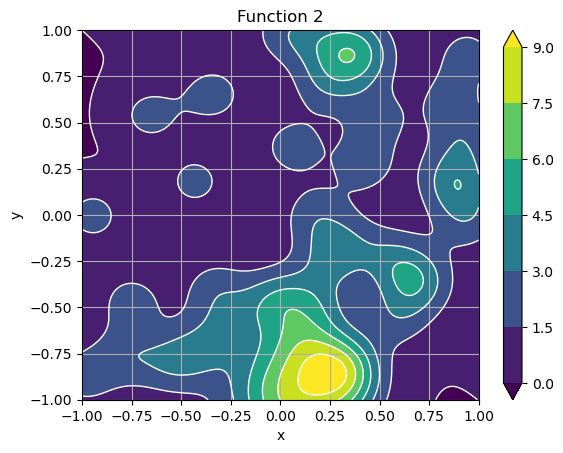

In [5]:
num = 2
fname = 'data/func' + str(num) + '.pkl'

# Function parameters
d = 2
n_maxima = 40
global_mag = 8
local_mag = 2
alpha = 0.1
beta = 0.03
gamma = 0.1

# Create functions
func = sumOfGaussians(
    d = d,
    n_maxima = n_maxima,
    global_mag = global_mag,
    local_mag = local_mag,
    alpha = alpha,
    beta = beta,
    gamma = gamma
)

visualizeObj(func, bounds = torch.tensor([[-1, -1], [1, 1]], dtype = torch.double), train_X = None, resolution = 200, title = 'Function %d' %num)

In [ ]:
# Save the function
# with open(fname, 'wb') as file:
#     pickle.dump(func, file)

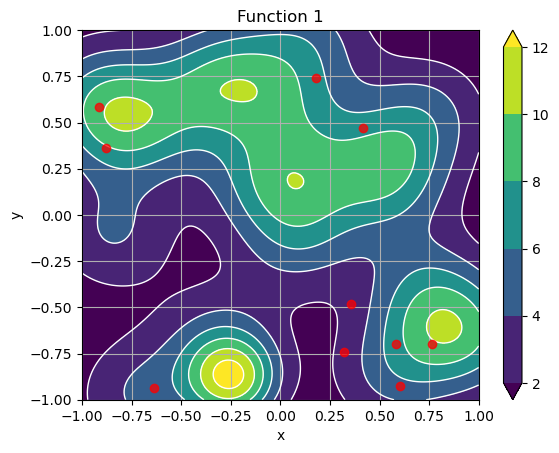

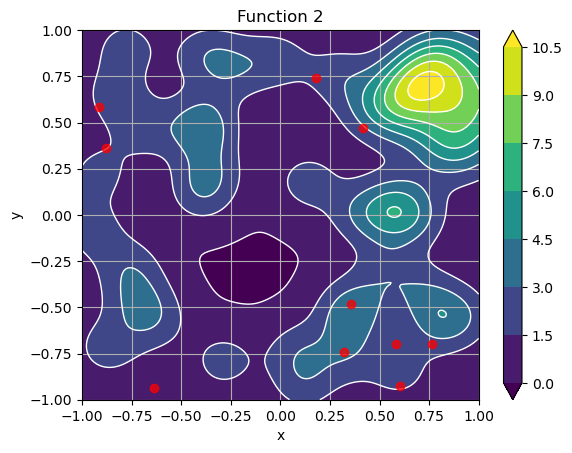

In [6]:
# Sample training points randomly
n_init = 10
d = 2
train_X = torch.DoubleTensor(n_init, d).uniform_(-1,1)

# Plot the training points on the function
num = 1
fname = 'data/func' + str(num) + '.pkl'

with open(fname, 'rb') as file:
    func = pickle.load(file)

visualizeObj(func, bounds = torch.tensor([[-1, -1], [1, 1]], dtype = torch.double), train_X = train_X, resolution = 200, title = 'Function %d' %num)

# Plot the training points on the function
num = 2
fname = 'data/func' + str(num) + '.pkl'

with open(fname, 'rb') as file:
    func = pickle.load(file)

visualizeObj(func, bounds = torch.tensor([[-1, -1], [1, 1]], dtype = torch.double), train_X = train_X, resolution = 200, title = 'Function %d' %num)

In [28]:
# Optionally, save the training points
outname = 'data/train' + str(num) + '.pt'
torch.save(train_X, outname)

In [15]:
bounds = torch.tensor([[-1, -1], [1, 1]], dtype = torch.float64)
resolution = 200

xs = torch.linspace(bounds[0][0], bounds[1][0], resolution, dtype = torch.double)
ys = torch.linspace(bounds[0][1], bounds[1][1], resolution, dtype = torch.double)
Xs, Ys = torch.meshgrid(xs, ys, indexing = 'ij')

func.eval(torch.cat([Xs.reshape(-1,1), Ys.reshape(-1,1)], dim = 1)).min()

tensor(-0.0972, dtype=torch.float64)